# A/B Testing on Marketing Data — Ad vs PSA

For this project I wanted to practice A/B testing on a real dataset instead of just reading about it. I used the Marketing A/B Testing dataset from Kaggle, where one group of users was shown an ad and another group (control) was shown a PSA (public service announcement) instead.

**Question I'm trying to answer:** Did showing the ad actually lead to more conversions, or could the difference we see just be random luck?

I'll go through this step by step — load the data, explore it a bit, check if the sample size is even big enough to trust a result, run the actual statistical test, and then try to explain what it means in plain terms.

## Step 1: Load and look at the data

First I'll load the CSV and just look at what's inside — shape, column names, and the first few rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("marketing_AB.csv")
print("Shape:", df.shape)
df.head()

Shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


There's an extra `Unnamed: 0` column which is just a leftover index from when the CSV was saved, so that's not useful to me. Let me check the columns and data types properly.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 32.6 MB


In [3]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

No missing values, which is nice — one less thing to deal with. I'll drop the index column since it's not going to help with anything.

In [4]:
df = df.drop(columns=["Unnamed: 0"])
df.shape

(588101, 6)

## Step 2: How big is each group, and what's the conversion rate?

Before I test anything, I want to see the basic numbers — how many people are in the ad group vs the psa group, and how many of them converted.

In [5]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

That's a big imbalance — way more people saw the ad than the psa. That makes sense for a real company (you don't want to hold back your actual ad from most users), but it's worth keeping in mind since it affects how confident we can be about the smaller group.

In [6]:
conversion_rate = df.groupby("test group")["converted"].mean()
print(conversion_rate)

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


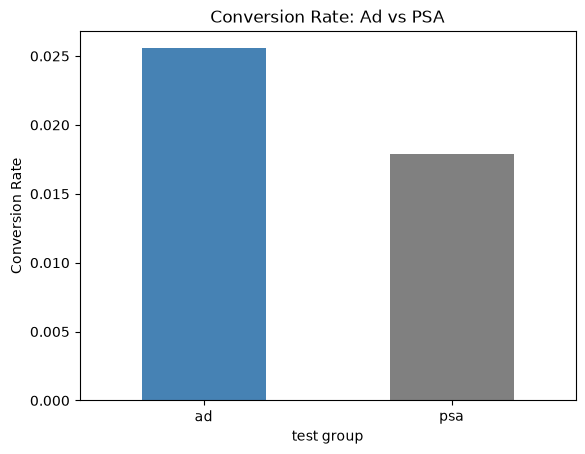

In [7]:
conversion_rate.plot(kind="bar", color=["steelblue", "grey"])
plt.title("Conversion Rate: Ad vs PSA")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.show()

So on the surface, the ad group converted at about **2.55%** and the psa group at about **1.79%**. That's a difference, but with a dataset this size I can't just eyeball it and say "ad wins" — I need to actually test if this gap is statistically meaningful or if it could just be random noise, since even random groups won't have the *exact* same conversion rate by chance.

## Step 3: Setting up the hypothesis test

Before running any test, I'm writing down what I'm actually testing (my mentor pointed out that deciding this *after* looking at the result kind of defeats the purpose):

- **Null hypothesis (H0):** There's no real difference in conversion rate between the ad group and the psa group.
- **Alternative hypothesis (H1):** The ad group has a higher conversion rate than the psa group.
- **Significance level:** I'm using the standard 0.05 (5%).

If the p-value comes out under 0.05, I'll reject H0 and conclude the ad group really does convert better.

## Step 4: Is the sample size actually big enough?

This is a step I almost skipped, but it matters — statistical tests can technically run on any amount of data, but that doesn't mean the result is trustworthy if the sample is too small. So before trusting the p-value later, I wanted to check: given the psa group's conversion rate, how many users would we need per group to reliably detect something like a 20% relative improvement?

In [8]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = df.loc[df["test group"] == "psa", "converted"].mean()
expected_rate = baseline_rate * 1.20  # assuming a 20% relative lift

effect_size = proportion_effectsize(baseline_rate, expected_rate)

power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    alternative="two-sided"
)

print(f"Baseline (PSA) conversion rate: {baseline_rate:.4f}")
print(f"Required sample size per group: {required_n:.0f}")
print("Actual group sizes:")
print(df["test group"].value_counts())

Baseline (PSA) conversion rate: 0.0179
Required sample size per group: 23655
Actual group sizes:
test group
ad     564577
psa     23524
Name: count, dtype: int64


The required sample size per group came out to around 23,655. The psa group has 23,524 — about 131 users short of that. It's worth being precise about what this actually means: this is a *planning* calculation based on an *assumed* 20% relative improvement, not a judgement on the test I already ran. Being slightly under this number doesn't mean the hypothesis test itself is invalid — the p-value and CI below are still computed correctly regardless. It's just a limitation worth flagging, not a reason to distrust the result.

## Step 5: Running the actual test

Since `converted` is a yes/no (binary) outcome and I'm comparing two independent groups, the right test here is a **two-proportion z-test** — not a t-test, since t-tests are for comparing means of continuous data, not proportions. This tripped me up at first since a lot of tutorials just default to t-tests for everything.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby("test group")["converted"].sum()
sample_sizes = df["test group"].value_counts()

count = [conversions["ad"], conversions["psa"]]
nobs = [sample_sizes["ad"], sample_sizes["psa"]]

z_stat, p_value = proportions_ztest(count=count, nobs=nobs, alternative="larger")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: 7.3701
P-value: 0.000000


P-value is basically 0 (way under 0.05), so I'm rejecting H0. Statistically, the ad group's higher conversion rate is not just random noise.

But a p-value alone doesn't tell me *how much* better — for that I need the actual size of the difference, which is the next thing to check.

In [10]:
from statsmodels.stats.proportion import confint_proportions_2indep

ad_rate = conversion_rate["ad"]
psa_rate = conversion_rate["psa"]
absolute_difference = ad_rate - psa_rate
relative_lift = absolute_difference / psa_rate

ci_low, ci_high = confint_proportions_2indep(
    count1=conversions["ad"], nobs1=sample_sizes["ad"],
    count2=conversions["psa"], nobs2=sample_sizes["psa"]
)

print(f"Ad conversion rate: {ad_rate*100:.4f}%")
print(f"PSA conversion rate: {psa_rate*100:.4f}%")
print(f"Absolute difference: {absolute_difference*100:.4f}%")
print(f"Relative lift: {relative_lift*100:.2f}%")
print(f"95% CI for difference: ({ci_low*100:.4f}%, {ci_high*100:.4f}%)")

Ad conversion rate: 2.5547%
PSA conversion rate: 1.7854%
Absolute difference: 0.7692%
Relative lift: 43.09%
95% CI for difference: (0.5873%, 0.9360%)


So the ad group converts about 0.77 percentage points higher in absolute terms, which is a **43% relative lift** over the psa baseline. The 95% confidence interval (0.60% to 0.94%) doesn't cross zero, which lines up with the test being significant.

That said, I want to be careful here: a large *relative* lift doesn't automatically mean it's a big win for the business. Whether this is *practically* meaningful depends on things I don't have in this dataset — cost per ad shown, revenue per conversion, profit margin, and so on. Without those, I can say the effect is statistically real, but I can't actually say whether it's worth the ad spend.

## Step 6: Does the ad group still beat PSA on every day?

The overall result says the ad group converts better, but I wanted to check this isn't just being driven by one unusually good day. Both groups actually have a `most ads day` column, so I can build a proper day-by-day comparison instead of just looking at the ad group alone.

In [11]:
day_pivot = df.pivot_table(
    index="most ads day",
    columns="test group",
    values="converted",
    aggfunc="mean"
) * 100

day_pivot = day_pivot.round(2)
day_pivot

test group,ad,psa
most ads day,,
Friday,2.25,1.63
Monday,3.32,2.26
Saturday,2.13,1.40
Sunday,2.46,2.06
Thursday,2.16,2.02
Tuesday,3.04,1.44
Wednesday,2.54,1.58


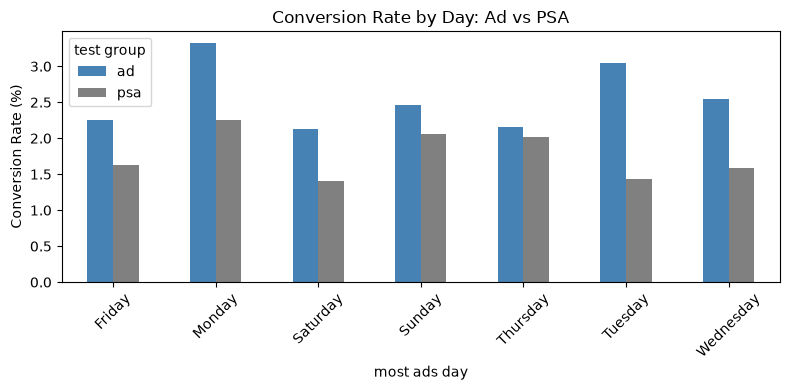

In [12]:
day_pivot.plot(kind="bar", figsize=(8,4), color=["steelblue", "grey"])
plt.title("Conversion Rate by Day: Ad vs PSA")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The ad group beats the psa group on every single day — the gap isn't being driven by one outlier day, and it's not reversed on any day either (which would've been a red flag, since that's what a Simpson's paradox situation would look like). The gap does vary in size by day — biggest on Monday and Tuesday (~1 percentage point), smallest on Thursday (~0.14 points) — but the direction is consistent throughout, which makes me more confident the overall result isn't a fluke of the data.

## Conclusion

To answer the original question: yes, showing the ad was associated with a statistically significant increase in conversion rate compared to the psa control (p < 0.05, 95% CI 0.60%–0.94%), and this holds consistently across every day of the week, not just on average.

The observed 0.77 percentage-point improvement (43% relative lift) is statistically significant and may be practically meaningful, but I can't determine its financial significance from this dataset alone — that would require cost-per-ad and revenue-per-conversion data, which isn't included here.

**Limitations I'm aware of:**
- The psa group was slightly below the sample size the power analysis estimated would be needed to reliably detect an assumed 20% relative improvement. This is a planning-stage check, not a flaw in the test itself, but it's worth noting.
- This is observational-style A/B data from Kaggle, not something I ran myself, so I can't be fully certain users were randomly assigned the way a real controlled experiment would guarantee.
- I don't have cost or revenue data, so I stopped at statistical significance rather than claiming a business conclusion I can't actually support.

**What I'd do differently next time:** run the power calculation *before* collecting data rather than retroactively, and if this were a real business project, pair the statistical result with cost/revenue figures before recommending any action.